In [1]:
# 1. Подключаем Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. Основные пути

ZIP_PATH = "/content/drive/MyDrive/DigitalEpoch/hold_dataset.zip"

# Папка, куда будет распакован датасет внутри Colab
DATASET_ROOT = "/content/hold_dataset"

# Папка на Google Drive, куда будут сохраняться результаты обучения
PROJECT_DIR = "/content/drive/MyDrive/DigitalEpoch/runs"

print("ZIP_PATH:", ZIP_PATH)
print("DATASET_ROOT:", DATASET_ROOT)
print("PROJECT_DIR:", PROJECT_DIR)

ZIP_PATH: /content/drive/MyDrive/DigitalEpoch/hold_dataset.zip
DATASET_ROOT: /content/hold_dataset
PROJECT_DIR: /content/drive/MyDrive/DigitalEpoch/runs


In [3]:
# 3. Проверяем, что архив существует

import os

if os.path.exists(ZIP_PATH):
    print("Архив найден:", ZIP_PATH)
else:
    raise FileNotFoundError(
        f"Архив не найден: {ZIP_PATH}\n"
        "Проверь, что файл hold_dataset.zip загружен в Google Drive "
        "и путь ZIP_PATH указан правильно."
    )

Архив найден: /content/drive/MyDrive/DigitalEpoch/hold_dataset.zip


In [4]:
# 4. Очищаем старую папку датасета, если она уже была, и распаковываем архив

import shutil

if os.path.exists(DATASET_ROOT):
    shutil.rmtree(DATASET_ROOT)

os.makedirs(DATASET_ROOT, exist_ok=True)

!unzip -q "{ZIP_PATH}" -d "{DATASET_ROOT}"

print("Архив распакован в:", DATASET_ROOT)

Архив распакован в: /content/hold_dataset


In [5]:
# 5. Смотрим, что получилось после распаковки

!find "{DATASET_ROOT}" -maxdepth 4 -type d

/content/hold_dataset
/content/hold_dataset/labels
/content/hold_dataset/labels/train
/content/hold_dataset/labels/val
/content/hold_dataset/images
/content/hold_dataset/images/train
/content/hold_dataset/images/val
/content/hold_dataset/previews


In [6]:
# 6. Ищем data.yaml

import glob

yaml_files = glob.glob(DATASET_ROOT + "/**/data.yaml", recursive=True)

print("Найденные data.yaml:")
for file in yaml_files:
    print(file)

if not yaml_files:
    raise FileNotFoundError(
        "Файл data.yaml не найден. Проверь структуру архива."
    )

DATA_YAML = yaml_files[0]
print("\nБудет использоваться DATA_YAML:", DATA_YAML)

Найденные data.yaml:
/content/hold_dataset/data.yaml

Будет использоваться DATA_YAML: /content/hold_dataset/data.yaml


In [7]:
# 7. Показываем содержимое data.yaml

with open(DATA_YAML, "r", encoding="utf-8") as f:
    print(f.read())

path: "C:/de_vika/hold_dataset"
train: images/train
val: images/val
names:
  0: hold_cloud



In [14]:
# Исправляем data.yaml под пути Google Colab

from pathlib import Path
import yaml

dataset_path = Path(DATA_YAML).parent

fixed_data = {
    "path": str(dataset_path),
    "train": "images/train",
    "val": "images/val",
    "nc": 1,
    "names": ["hold_cloud"]
}

with open(DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(fixed_data, f, allow_unicode=True, sort_keys=False)

print("data.yaml исправлен:")
with open(DATA_YAML, "r", encoding="utf-8") as f:
    print(f.read())

data.yaml исправлен:
path: /content/hold_dataset
train: images/train
val: images/val
nc: 1
names:
- hold_cloud



In [8]:
# 8. Проверяем количество изображений и файлов разметки

from pathlib import Path

dataset_path = Path(DATA_YAML).parent

image_extensions = ["*.jpg", "*.jpeg", "*.png"]

train_images = []
val_images = []

for ext in image_extensions:
    train_images.extend((dataset_path / "images" / "train").glob(ext))
    val_images.extend((dataset_path / "images" / "val").glob(ext))

train_labels = list((dataset_path / "labels" / "train").glob("*.txt"))
val_labels = list((dataset_path / "labels" / "val").glob("*.txt"))

print("Папка датасета:", dataset_path)
print("Train images:", len(train_images))
print("Train labels:", len(train_labels))
print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

if len(train_images) == 0:
    print("ВНИМАНИЕ: train images не найдены.")
if len(val_images) == 0:
    print("ВНИМАНИЕ: val images не найдены.")

Папка датасета: /content/hold_dataset
Train images: 233
Train labels: 233
Val images: 67
Val labels: 67


In [9]:
# 9. Проверяем несколько файлов разметки

sample_labels = train_labels[:5] + val_labels[:5]

for label_file in sample_labels:
    print("\n---", label_file.name, "---")
    with open(label_file, "r", encoding="utf-8") as f:
        content = f.read().strip()
        print(content if content else "[пустой файл разметки]")


--- 00131_tsu-450_p003.txt ---
[пустой файл разметки]

--- 00095_rsh400-truva18m_p002.txt ---
0 0.509662 0.142460 0.222222 0.046561
0 0.635870 0.834259 0.240338 0.048697

--- 00114_kotel-200kvt-truba-10m_p002.txt ---
0 0.443237 0.294105 0.092995 0.060231

--- 00048_truba-dy450-8m_p002.txt ---
0 0.606280 0.895557 0.157005 0.034601
0 0.134662 0.327638 0.138889 0.080308
0 0.364432 0.856685 0.282005 0.047416
0 0.395833 0.466467 0.169686 0.039299
0 0.612017 0.444468 0.093599 0.120889

--- 00141_kotel-200kvt-truba-10m_p001.txt ---
0 0.428226 0.578812 0.240556 0.058095
0 0.770172 0.222982 0.231792 0.096540

--- 00166_kotel-200kvt-truba-10m_p001.txt ---
[пустой файл разметки]

--- 00287_truba-35m_p002.txt ---
0 0.580616 0.750748 0.283213 0.069628
0 0.200785 0.523067 0.277174 0.061939
0 0.142814 0.111491 0.150362 0.046134
0 0.688708 0.102947 0.105676 0.046134

--- 00256_2ismy_p002.txt ---
0 0.501208 0.394490 0.274155 0.052542
0 0.193237 0.098462 0.089372 0.034601
0 0.643418 0.743059 0.260266 0

In [10]:
# 10. Устанавливаем Ultralytics YOLO

!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.7 MB/s eta 0:00:00


In [11]:
# 11. Проверяем установку YOLO

import ultralytics
ultralytics.checks()

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.6/112.6 GB disk)


In [12]:
# 12. Проверяем, доступна ли GPU

import torch

print("CUDA доступна:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU не найдена. Обучение будет идти на CPU и может быть очень медленным.")

CUDA доступна: True
GPU: Tesla T4


In [16]:
# 13. Первый тестовый запуск обучения

# Для первого запуска берём лёгкую модель yolov8n.pt.
# imgsz=640 и batch=4 — безопасные параметры для бесплатного Colab.
# Если будет ошибка по памяти, уменьши batch до 2 или 1.

!yolo detect train \
  model=yolov8n.pt \
  data="{DATA_YAML}" \
  epochs=20 \
  imgsz=640 \
  batch=4 \
  project="{PROJECT_DIR}" \
  name=hold_cloud_test \
  exist_ok=True

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/hold_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hold_cloud_test, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

In [17]:
# 16. Проверяем, где лежат результаты

!find "{PROJECT_DIR}" -maxdepth 3 -type f | head -50

/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/weights/last.pt
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/weights/best.pt
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/args.yaml
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/labels.jpg
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/train_batch0.jpg
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/train_batch1.jpg
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/train_batch2.jpg
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/results.csv
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/train_batch590.jpg
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/train_batch591.jpg
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/train_batch592.jpg
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/val_batch0_labels.jpg
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/val_batch0_pred.jpg
/content/drive/MyDrive/DigitalEpoch/runs/hol

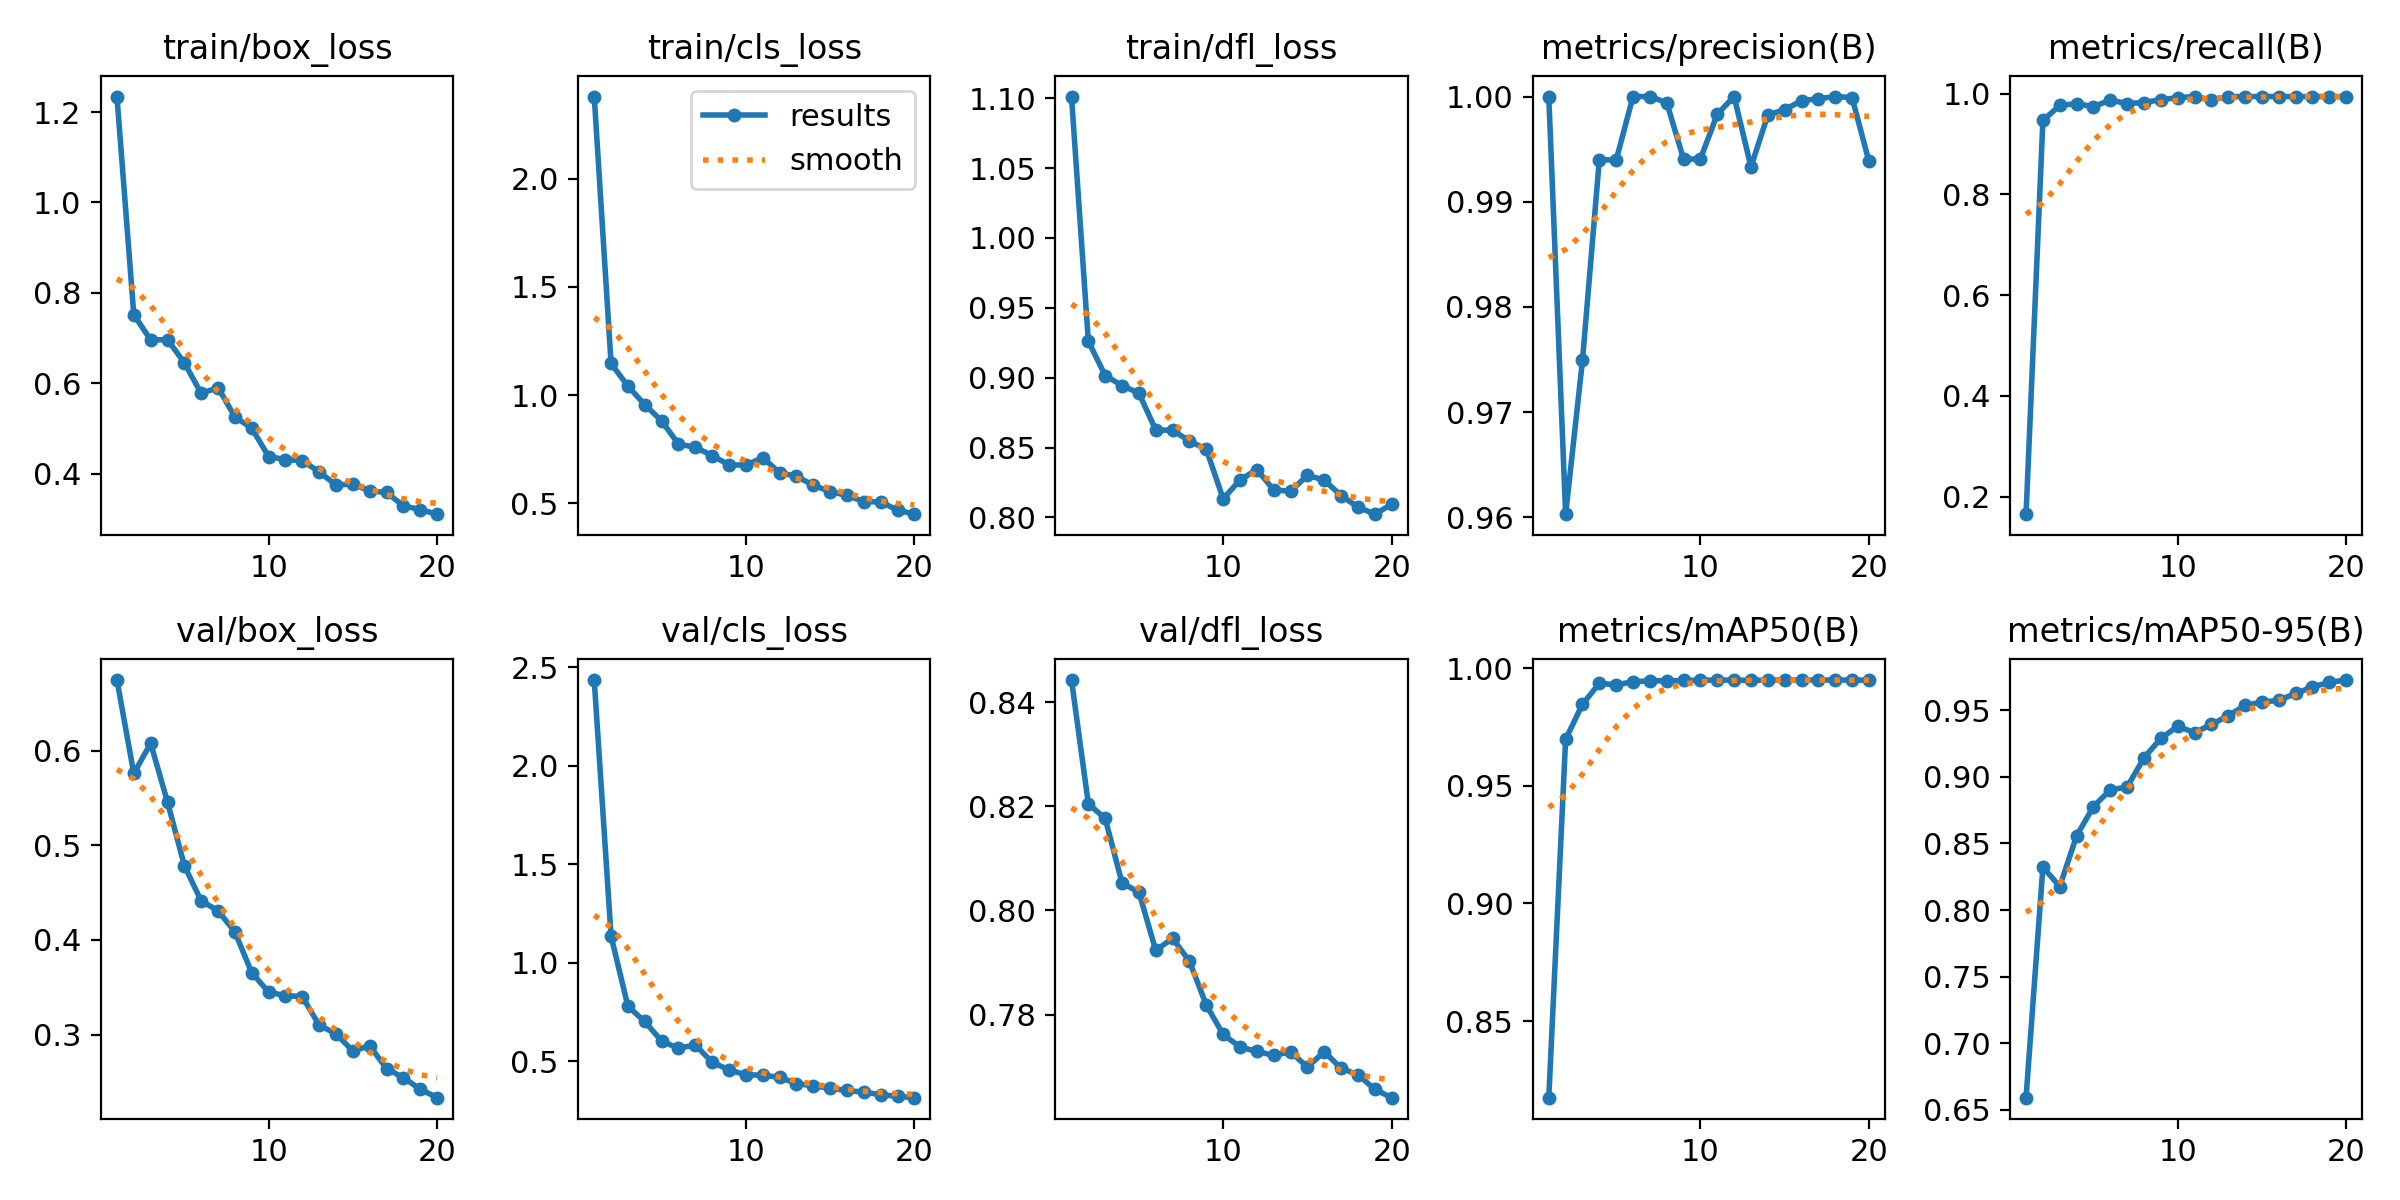

In [18]:
# 17. Показываем график результатов обучения, если он есть

from IPython.display import Image, display
import os

RESULTS_IMAGE = f"{PROJECT_DIR}/hold_cloud_test/results.png"

if os.path.exists(RESULTS_IMAGE):
    display(Image(filename=RESULTS_IMAGE))
else:
    print("results.png не найден по пути:", RESULTS_IMAGE)
    print("Проверь имя папки запуска в PROJECT_DIR.")

Найдено pred-картинок: 3
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/val_batch0_pred.jpg


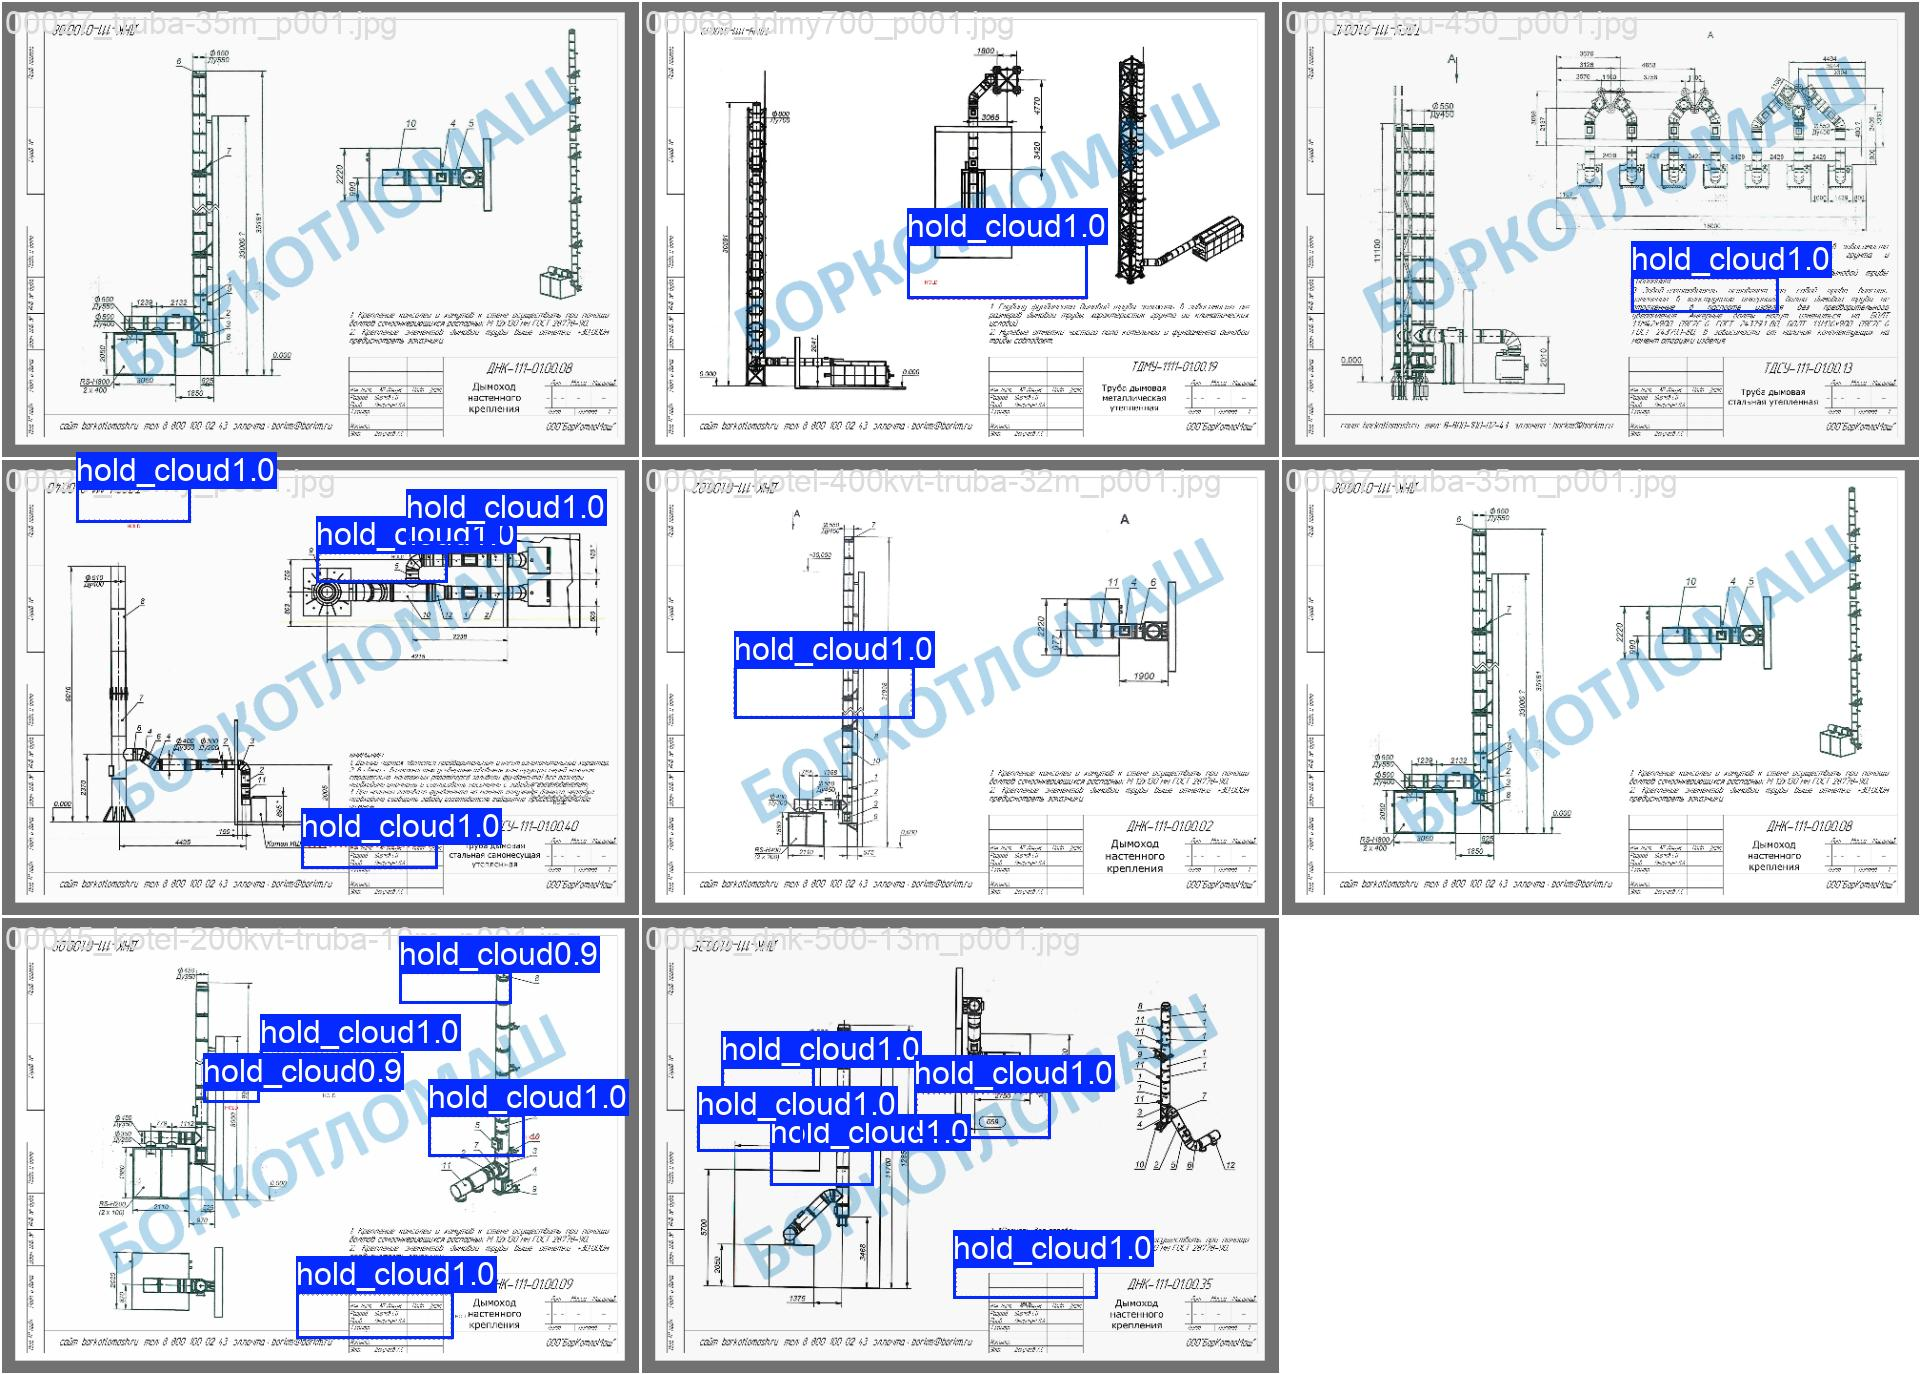

/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/val_batch1_pred.jpg


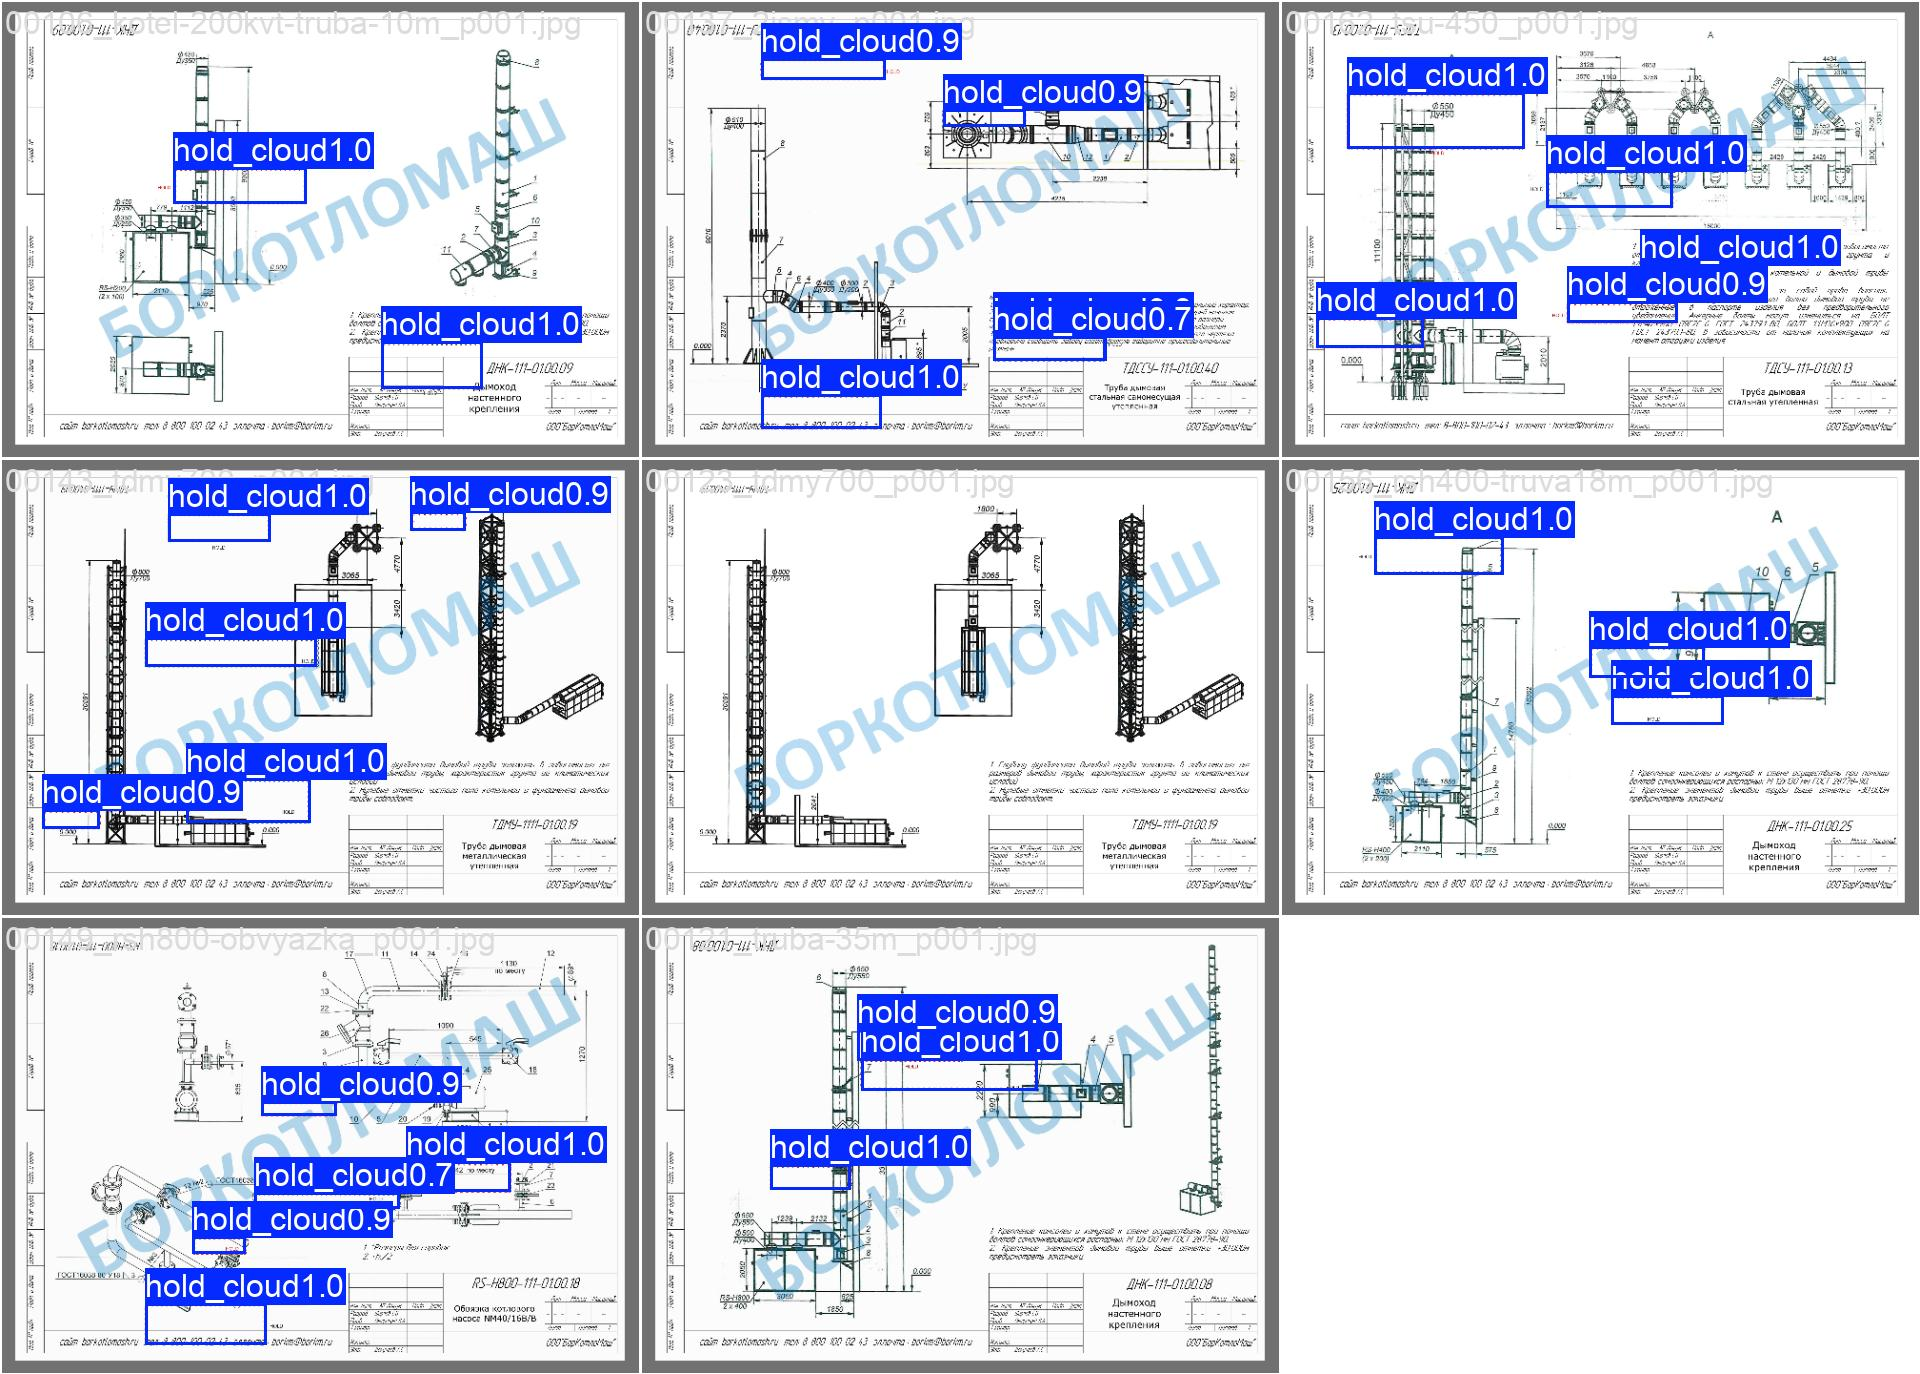

/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/val_batch2_pred.jpg


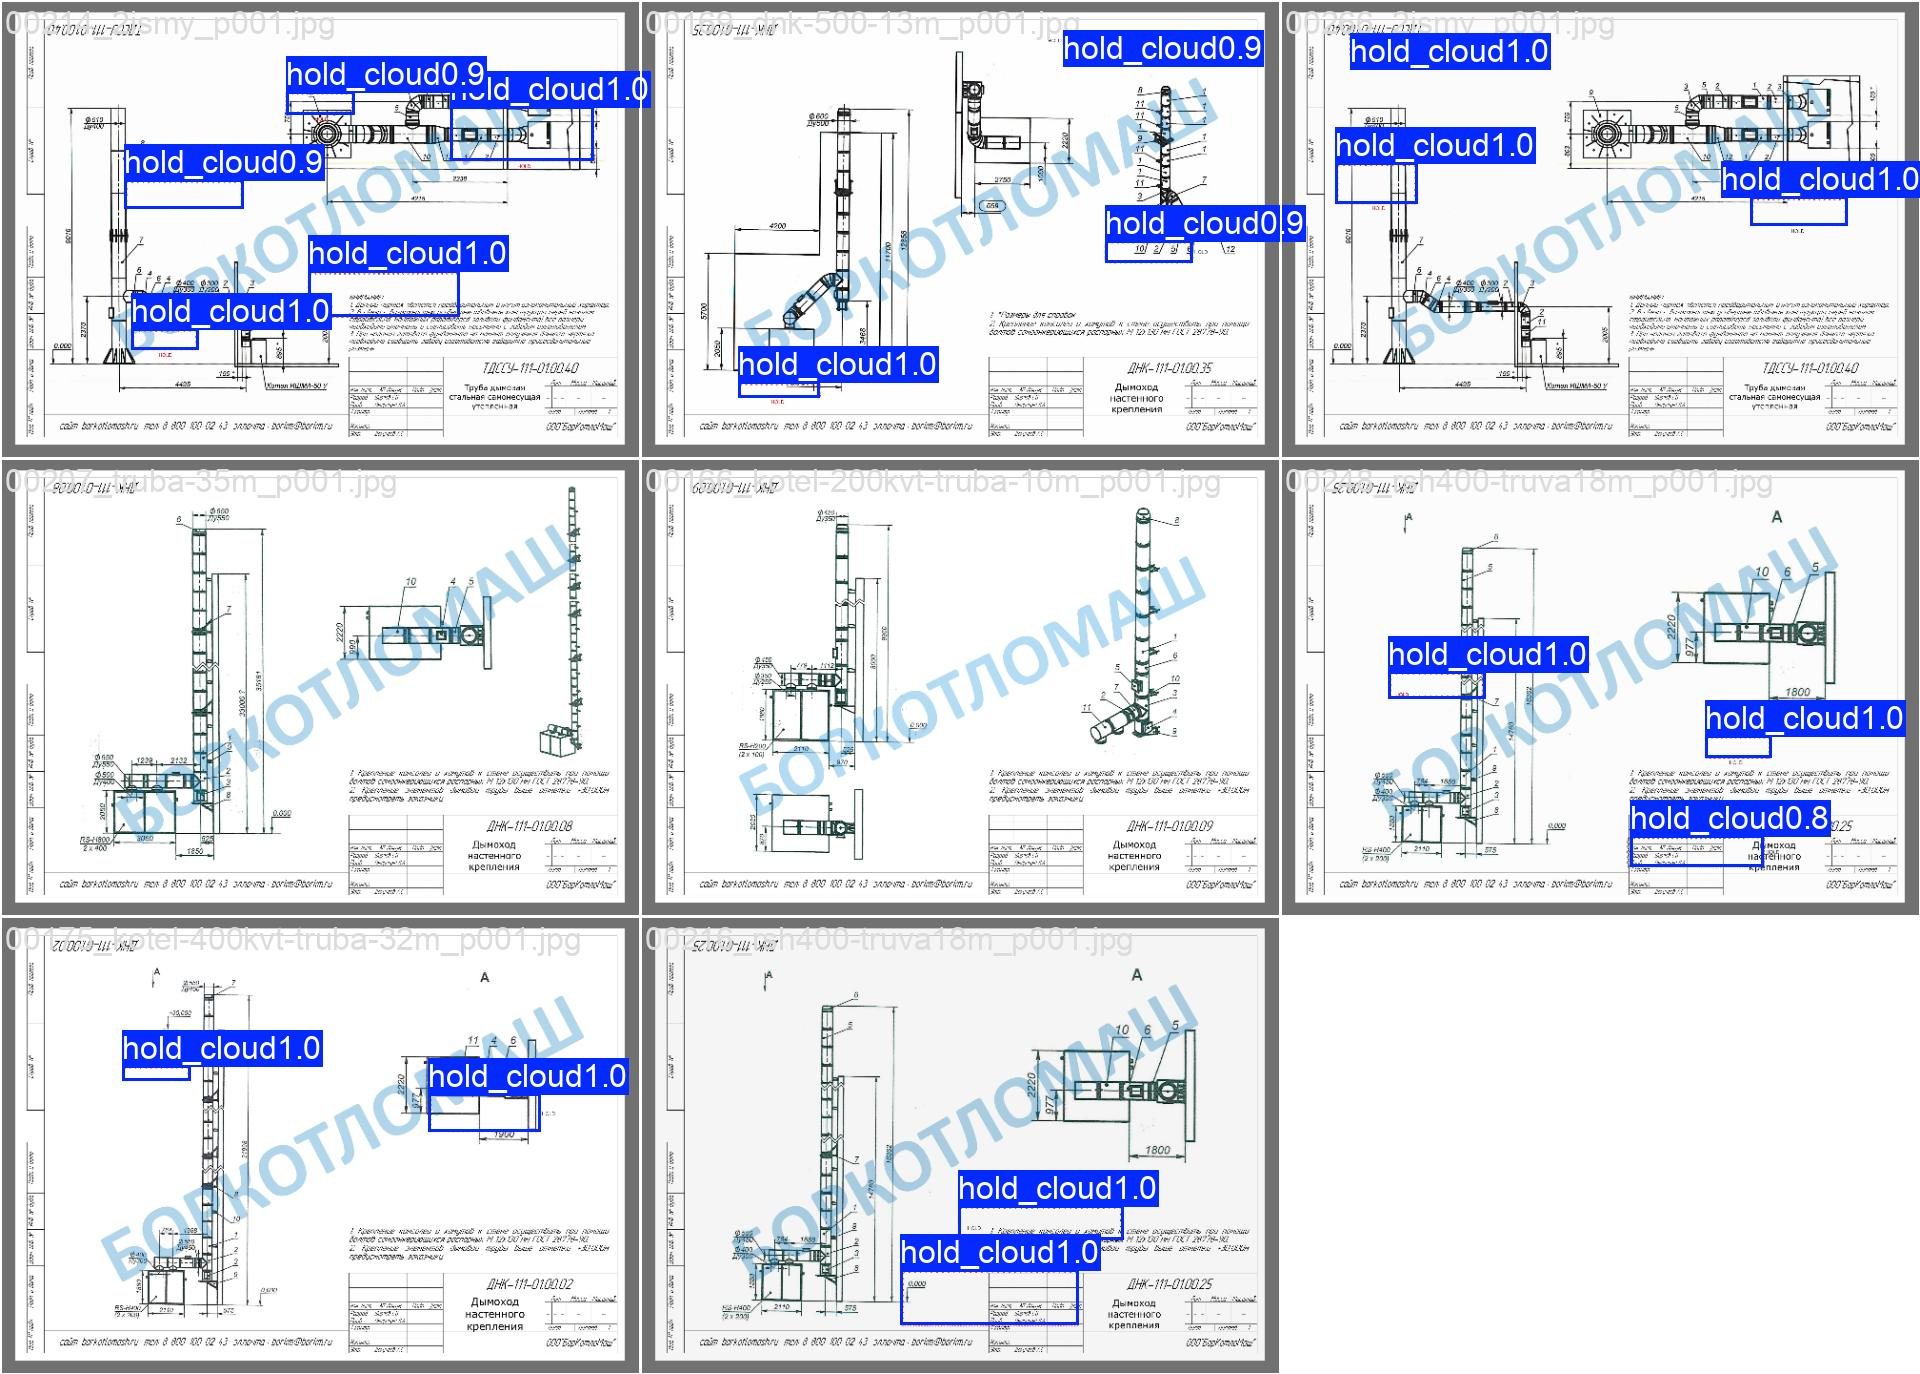

In [19]:
# 18. Показываем примеры validation-предсказаний, если они есть

import glob
from IPython.display import Image, display

pred_examples = glob.glob(f"{PROJECT_DIR}/hold_cloud_test/val_batch*_pred.jpg")

print("Найдено pred-картинок:", len(pred_examples))

for img_path in pred_examples[:3]:
    print(img_path)
    display(Image(filename=img_path))

In [20]:
# 19. Путь к лучшей обученной модели

BEST_MODEL = f"{PROJECT_DIR}/hold_cloud_test/weights/best.pt"

if os.path.exists(BEST_MODEL):
    print("Лучшая модель найдена:")
    print(BEST_MODEL)
else:
    print("best.pt не найден. Проверь, завершилось ли обучение успешно.")

Лучшая модель найдена:
/content/drive/MyDrive/DigitalEpoch/runs/hold_cloud_test/weights/best.pt


In [21]:
# 20. Запускаем предсказание на validation-изображениях

# Результаты сохранятся в Google Drive:
# /content/drive/MyDrive/DigitalEpoch/predict/hold_cloud_predict

VAL_IMAGES_DIR = str(dataset_path / "images" / "val")
PREDICT_DIR = "/content/drive/MyDrive/DigitalEpoch/predict"

!yolo detect predict \
  model="{BEST_MODEL}" \
  source="{VAL_IMAGES_DIR}" \
  imgsz=640 \
  conf=0.25 \
  save=True \
  project="{PREDICT_DIR}" \
  name=hold_cloud_predict \
  exist_ok=True

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/67 /content/hold_dataset/images/val/00002_rsh800-obvyazka_p002.jpg: 640x480 4 hold_clouds, 42.5ms
image 2/67 /content/hold_dataset/images/val/00003_dnk-500-13m_p002.jpg: 640x480 4 hold_clouds, 5.9ms
image 3/67 /content/hold_dataset/images/val/00005_rsh800-obvyazka_p003.jpg: 640x480 3 hold_clouds, 6.1ms
image 4/67 /content/hold_dataset/images/val/00016_dnk-500-13m_p002.jpg: 640x480 5 hold_clouds, 6.4ms
image 5/67 /content/hold_dataset/images/val/00021_2ismy_p001.jpg: 480x640 4 hold_clouds, 38.7ms
image 6/67 /content/hold_dataset/images/val/00026_kotel-400kvt-truba-32m_p002.jpg: 640x480 2 hold_clouds, 6.8ms
image 7/67 /content/hold_dataset/images/val/00027_truba-35m_p001.jpg: 480x640 (no detections), 6.7ms
image 8/67 /content/hold_dataset/images/val/00031_tdmy700_p003.jpg: 640x480 2 hold_clouds, 6.5ms
image 9/67 /conte

Найдено изображений с предсказаниями: 67
/content/drive/MyDrive/DigitalEpoch/predict/hold_cloud_predict/00002_rsh800-obvyazka_p002.jpg


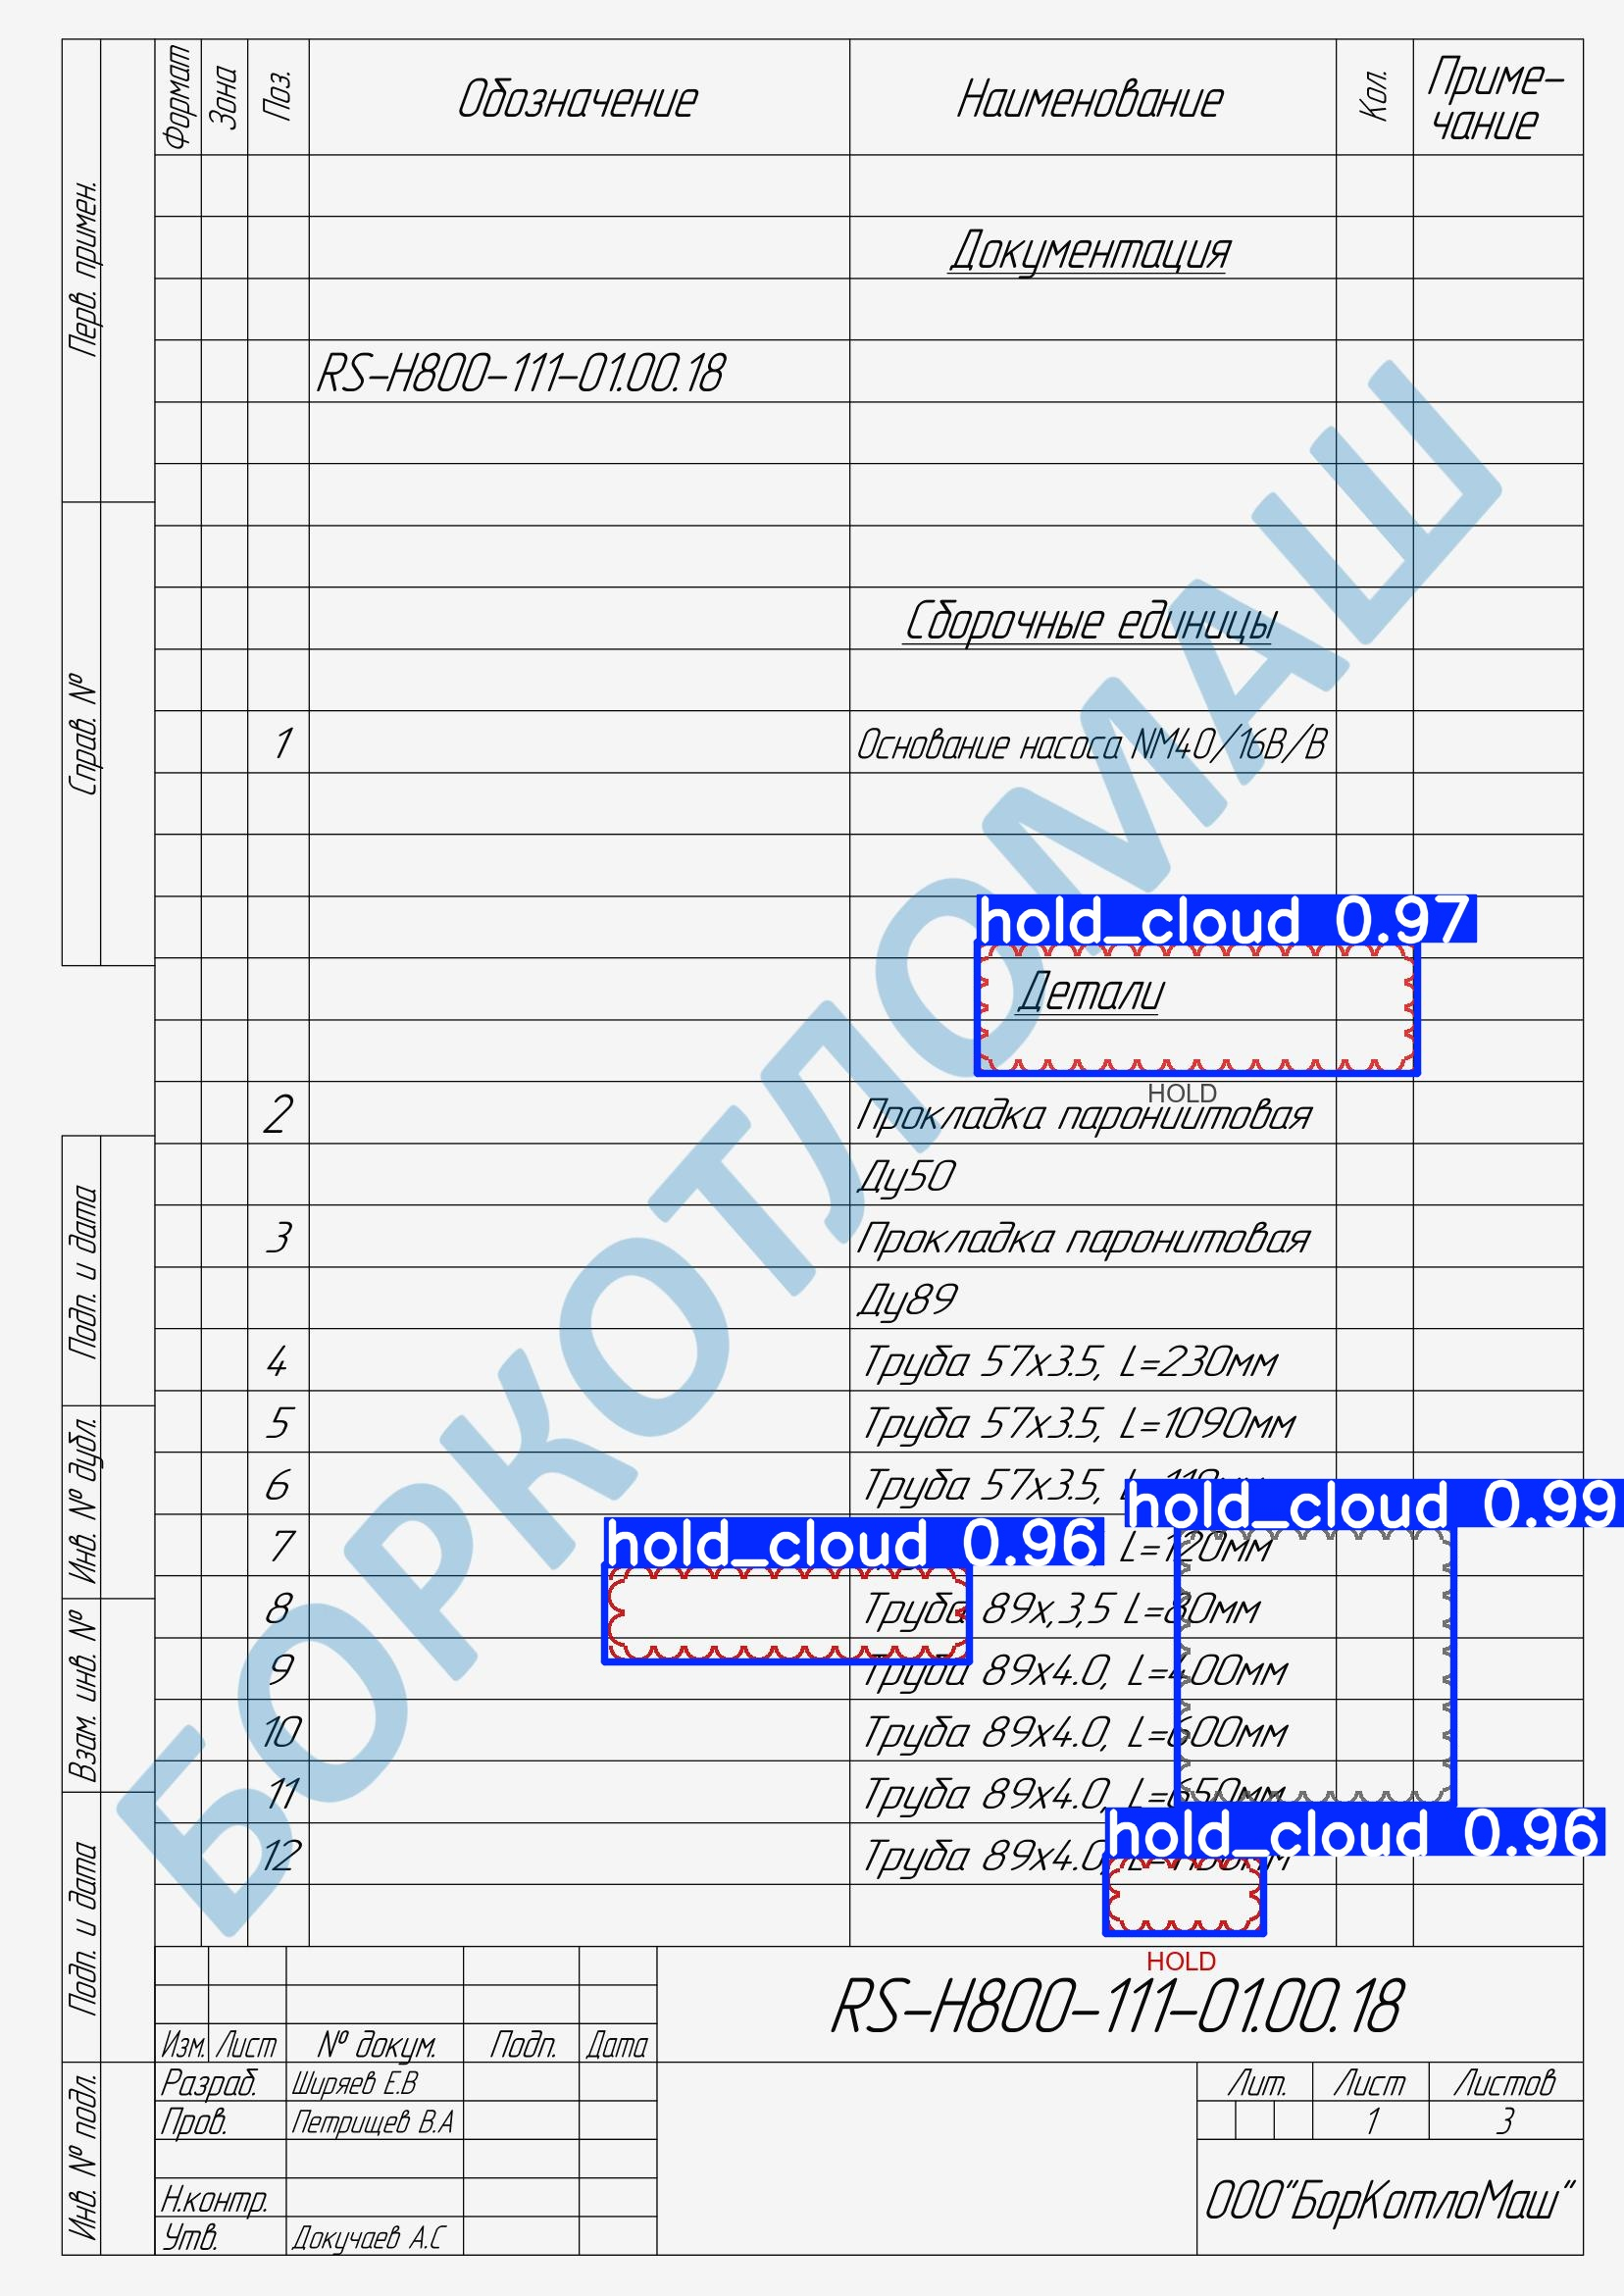

/content/drive/MyDrive/DigitalEpoch/predict/hold_cloud_predict/00003_dnk-500-13m_p002.jpg


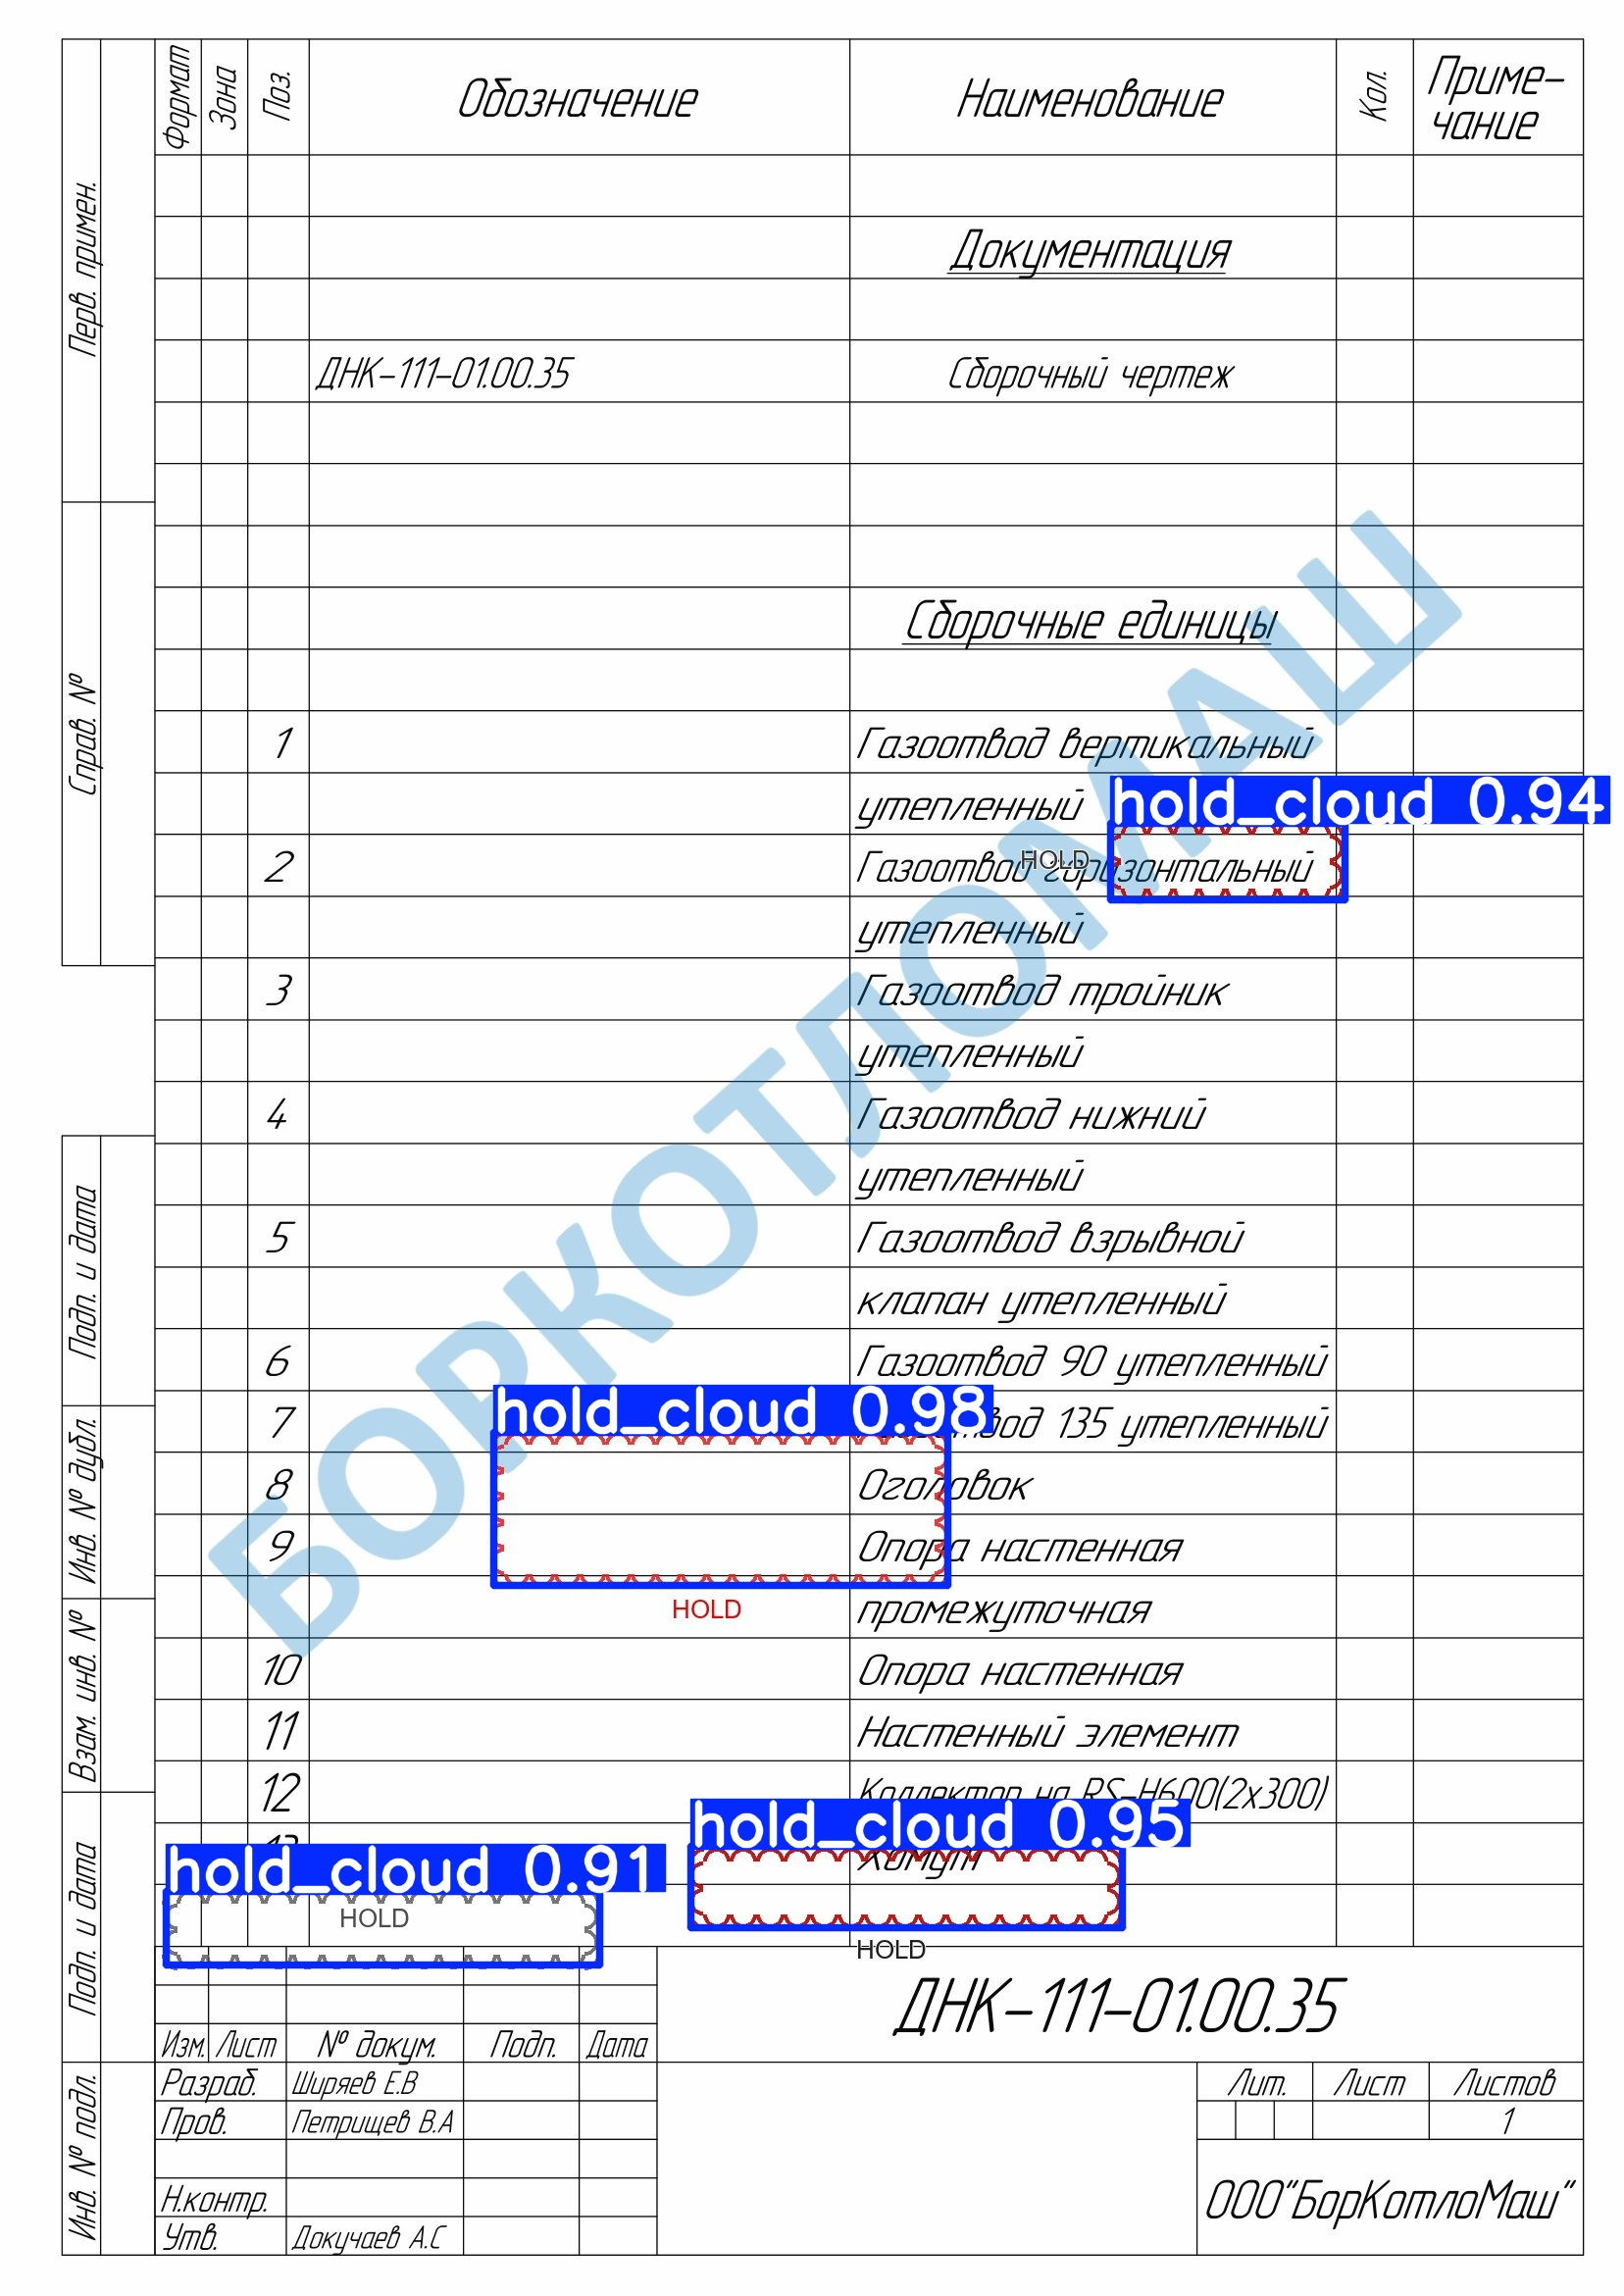

/content/drive/MyDrive/DigitalEpoch/predict/hold_cloud_predict/00005_rsh800-obvyazka_p003.jpg


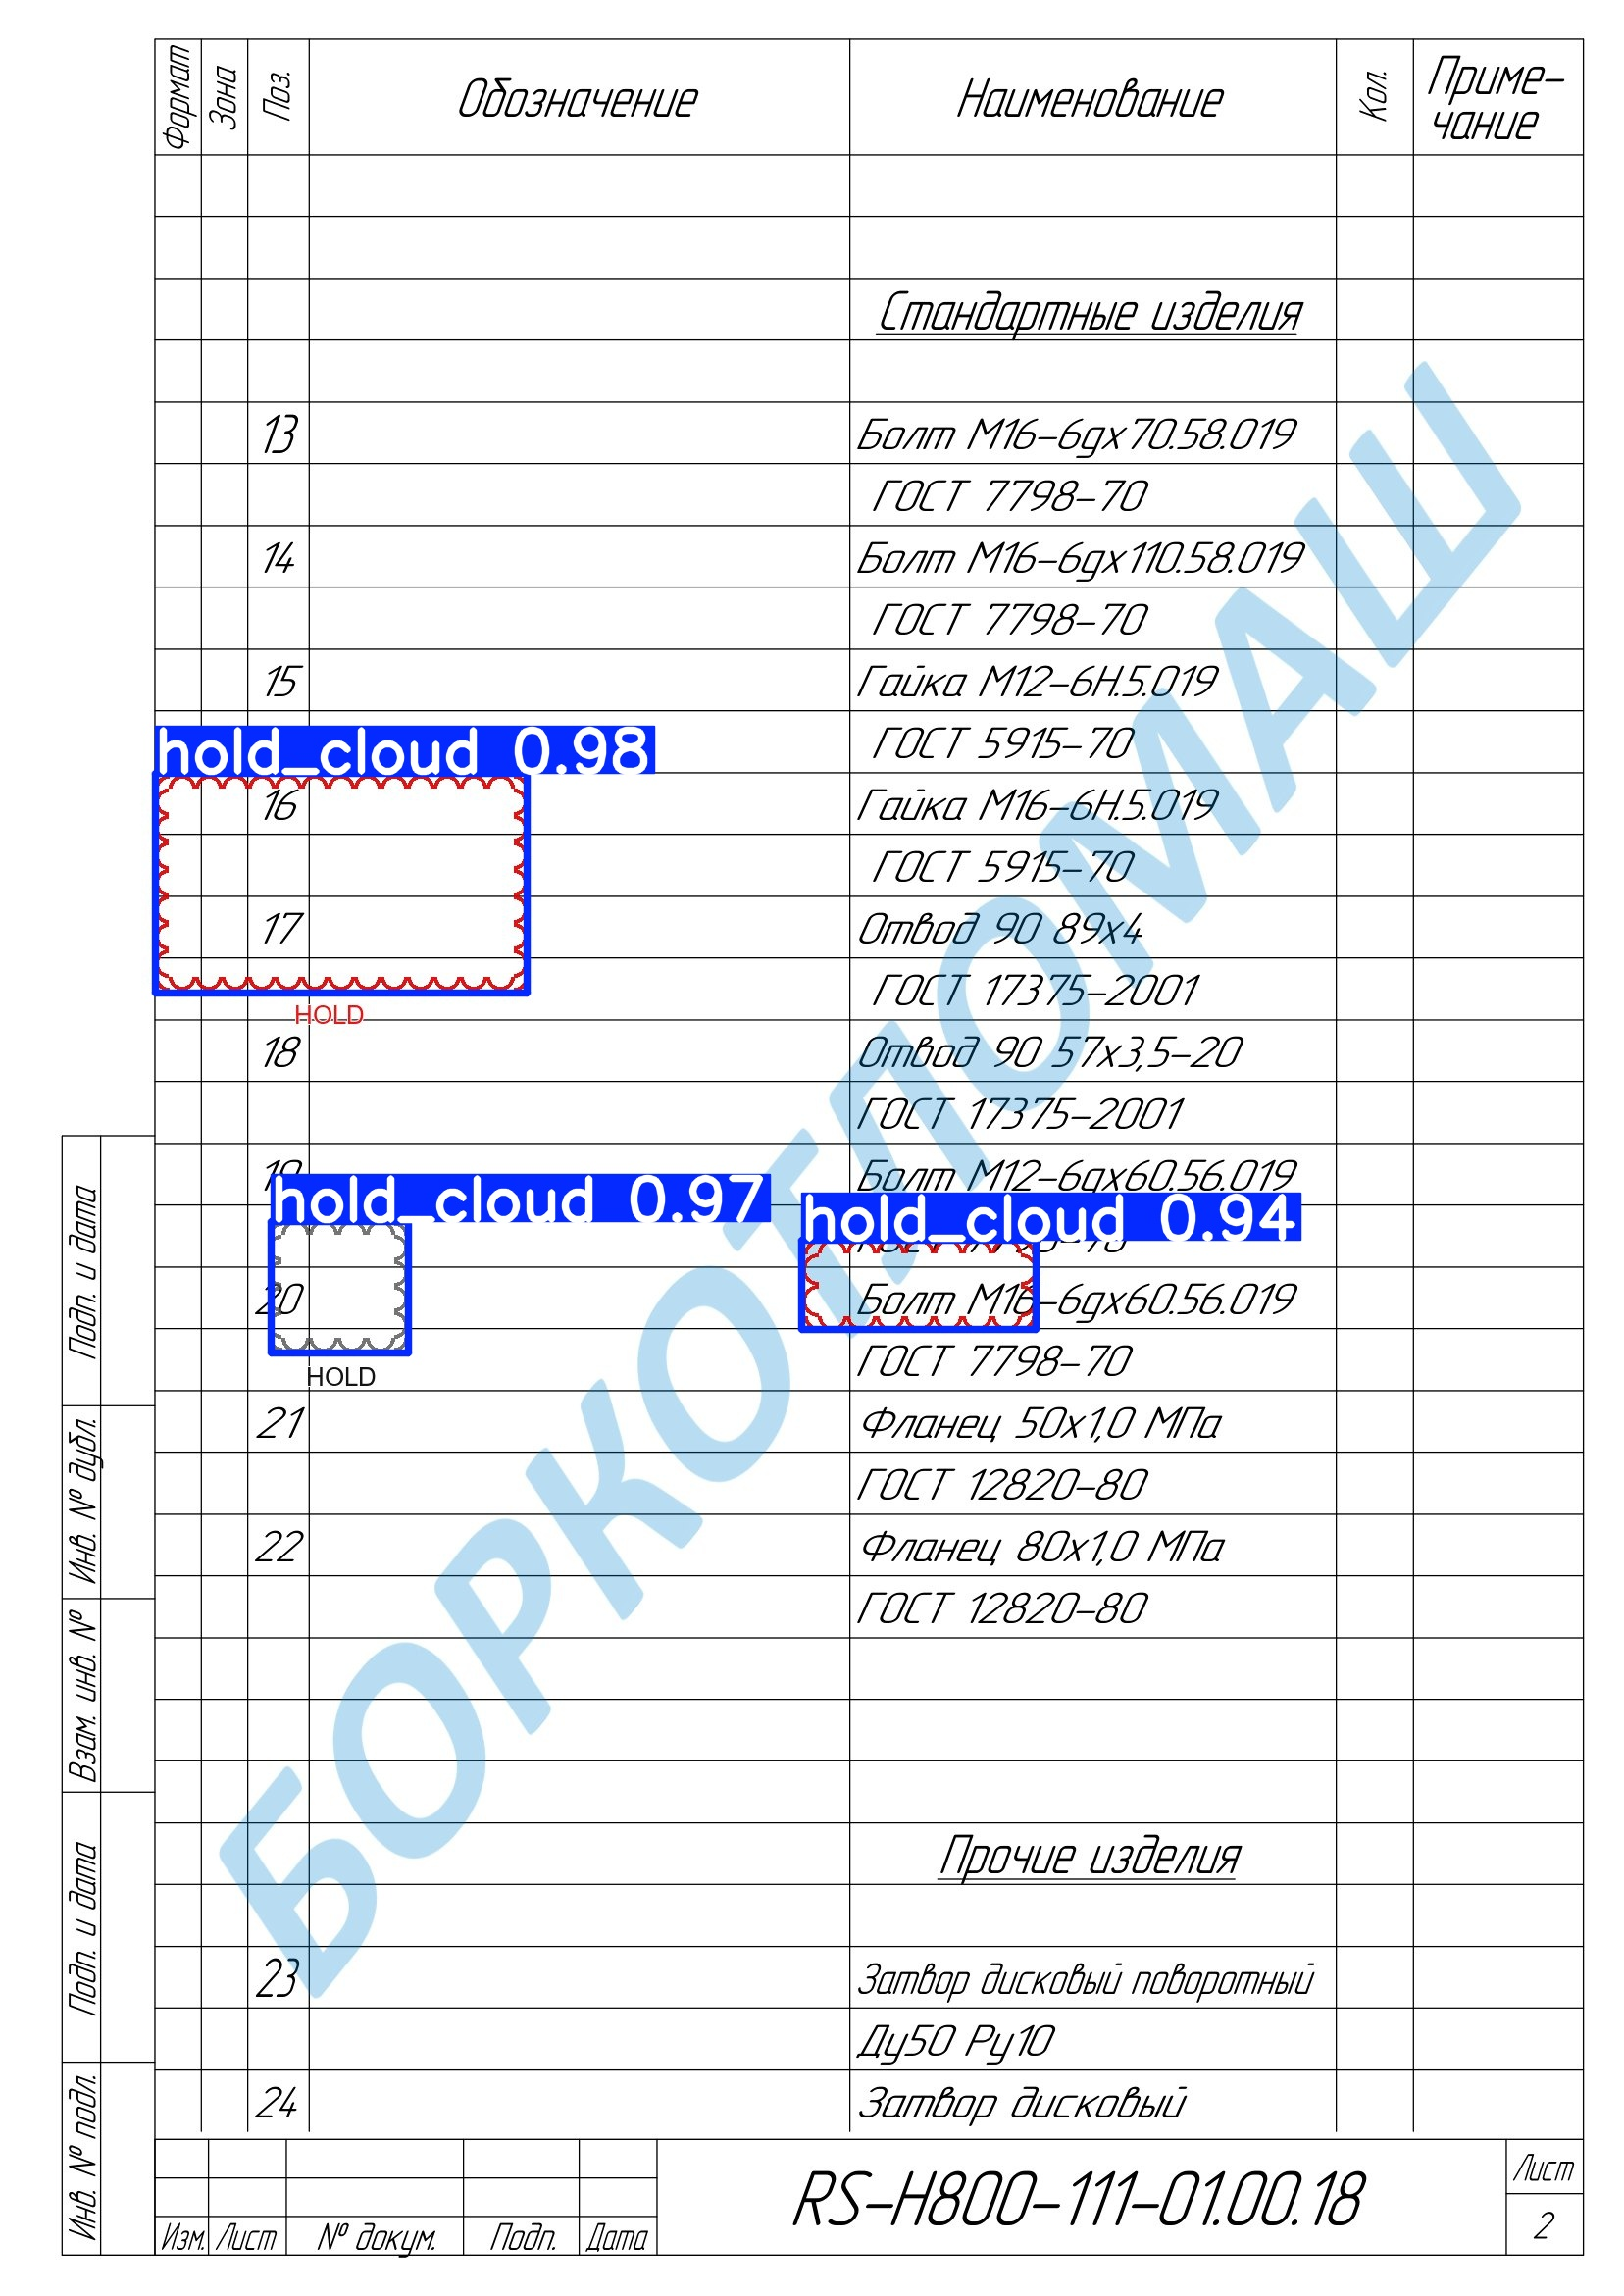

/content/drive/MyDrive/DigitalEpoch/predict/hold_cloud_predict/00016_dnk-500-13m_p002.jpg


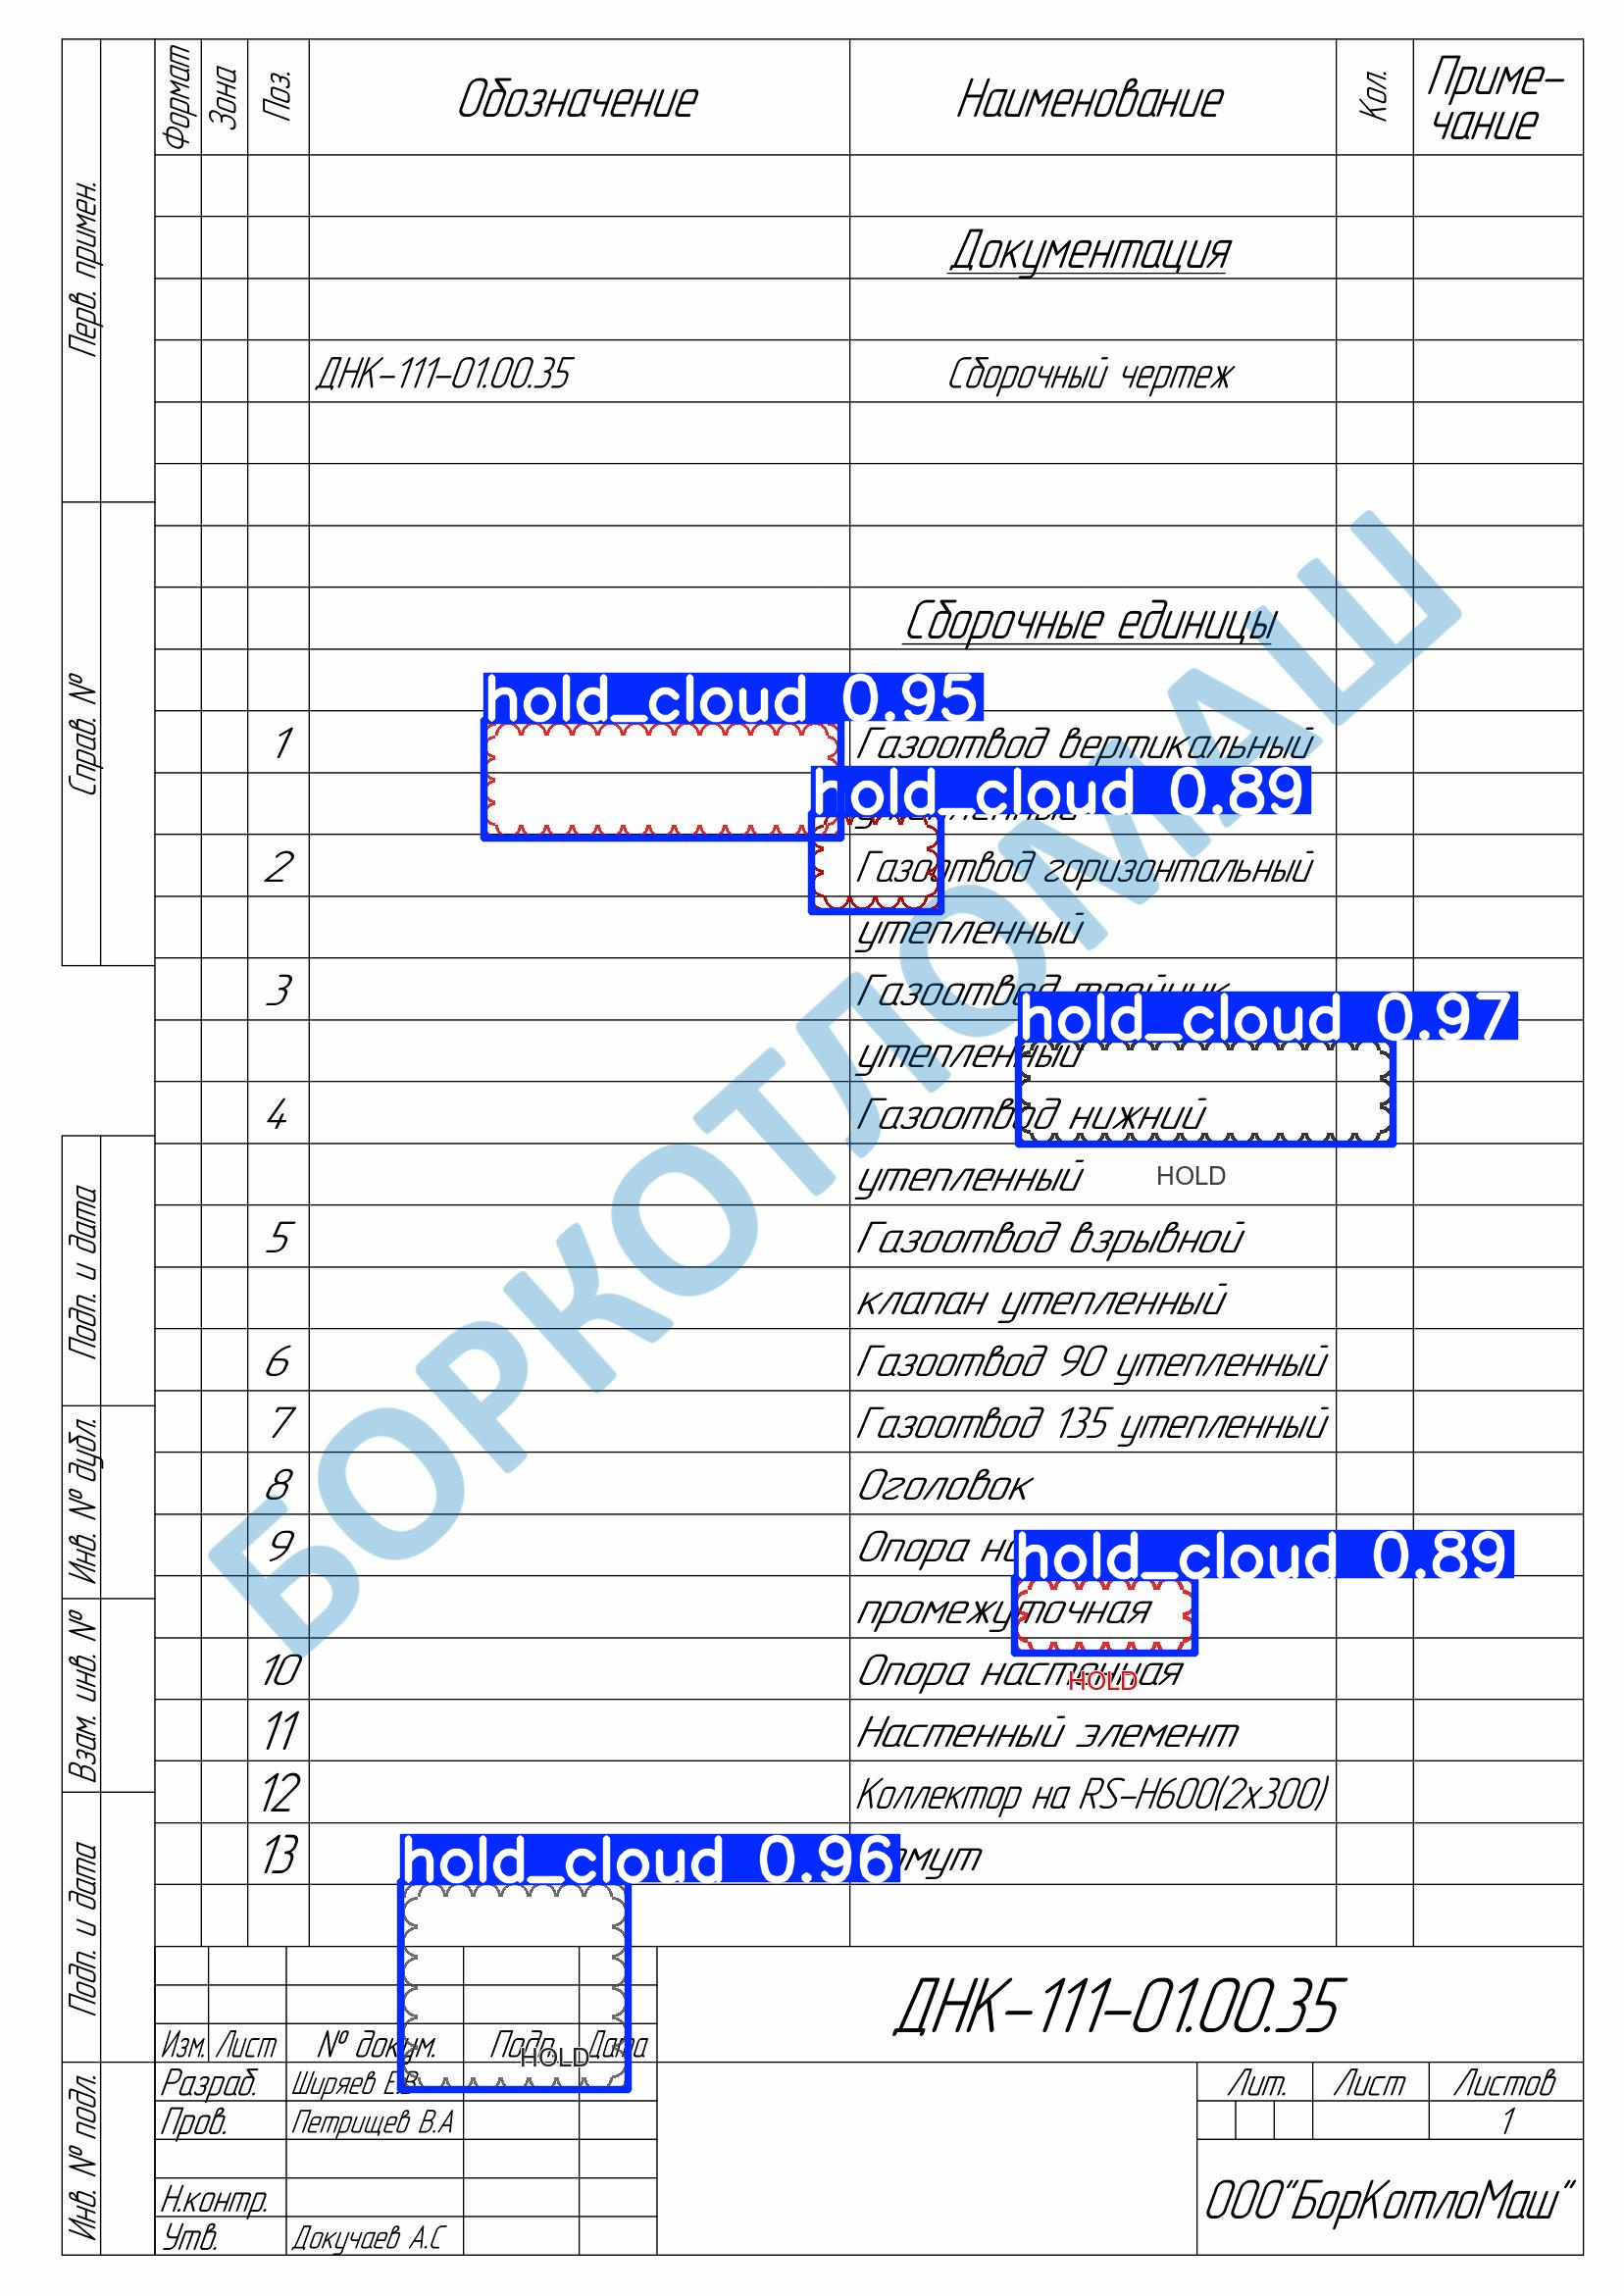

/content/drive/MyDrive/DigitalEpoch/predict/hold_cloud_predict/00021_2ismy_p001.jpg


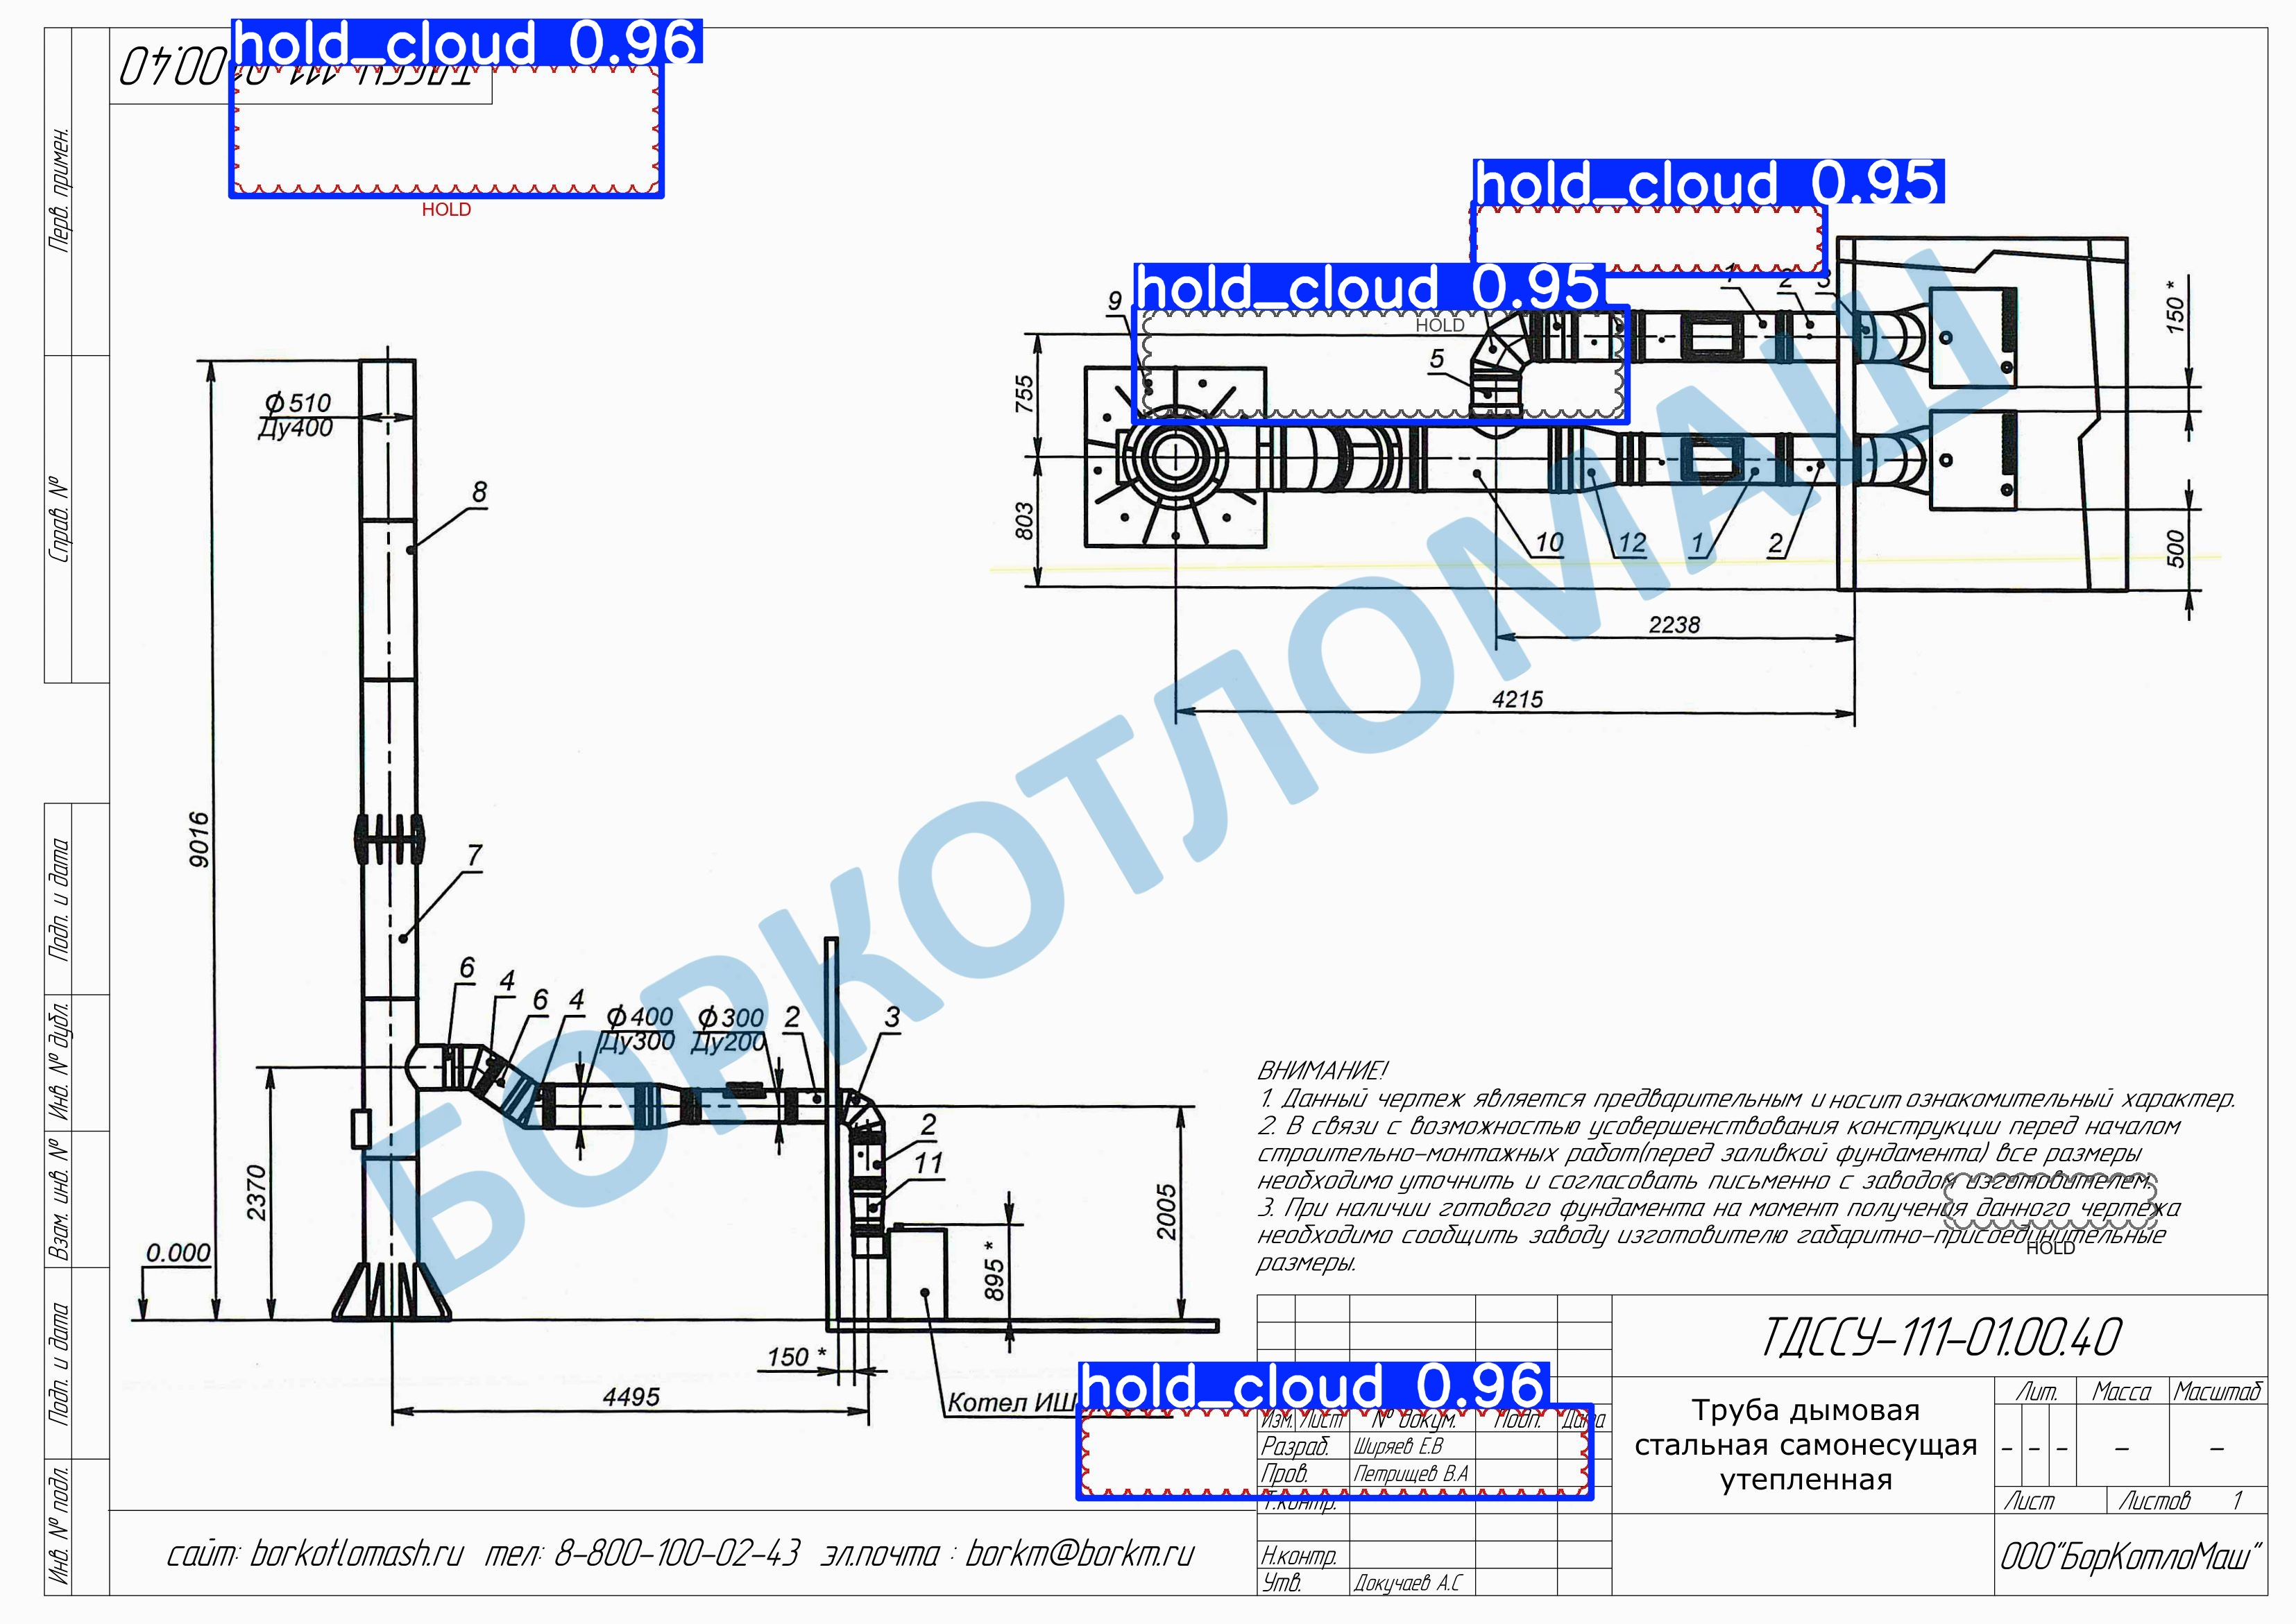

In [22]:
# 21. Показываем несколько изображений с предсказаниями

predict_images = glob.glob(f"{PREDICT_DIR}/hold_cloud_predict/*.jpg") + glob.glob(f"{PREDICT_DIR}/hold_cloud_predict/*.png")

print("Найдено изображений с предсказаниями:", len(predict_images))

for img_path in predict_images[:5]:
    print(img_path)
    display(Image(filename=img_path))

In [ ]:
# 22. Валидация модели отдельной командой

!yolo detect val \
  model="{BEST_MODEL}" \
  data="{DATA_YAML}" \
  imgsz=640 \
  project="{PROJECT_DIR}" \
  name=hold_cloud_val \
  exist_ok=True